         Graph         Library  Iteration  Mean_ms  Median_ms  CI_lower  \
0  patents.mtx  LAGraph-Normal          1    1.436      1.436     1.436   
1  patents.mtx  LAGraph-Normal          2    1.496      1.496     1.496   
2  patents.mtx  LAGraph-Normal          3    1.459      1.459     1.459   
3  patents.mtx  LAGraph-Normal          4    1.474      1.474     1.474   
4  patents.mtx  LAGraph-Normal          5    1.435      1.435     1.435   

   CI_upper  Std_Err  P_Normal  Sample_Size      GTEPS  
0     1.436      0.0       NaN          1.0  11.502383  
1     1.496      0.0       NaN          1.0  11.041057  
2     1.459      0.0       NaN          1.0  11.321057  
3     1.474      0.0       NaN          1.0  11.205849  
4     1.435      0.0       NaN          1.0  11.510399  


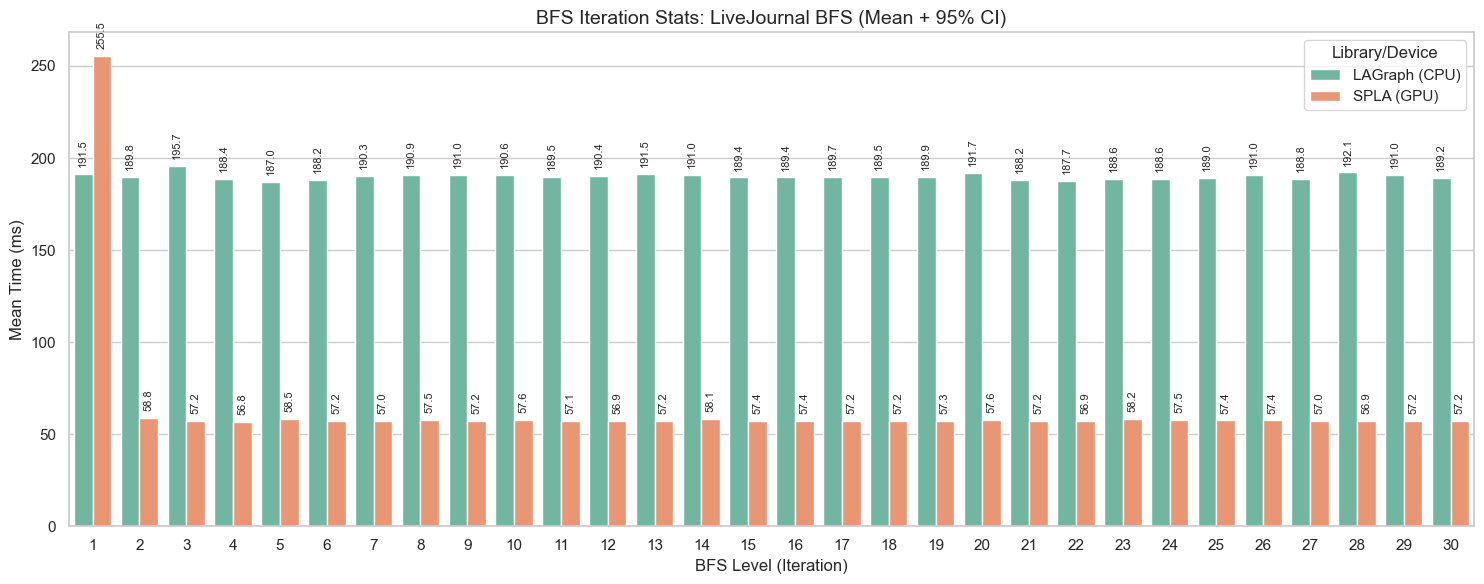

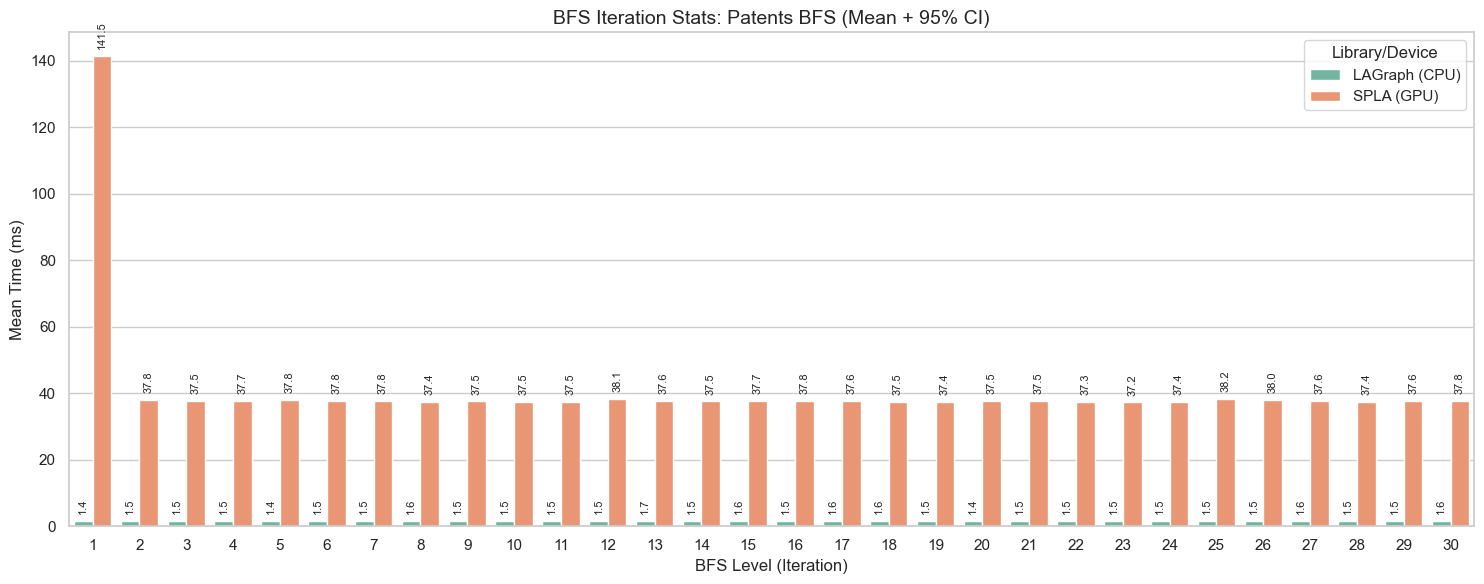

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Данные о графах (для GTEPS)
# В BFS GTEPS обычно считается как (сумма ребер в текущем фронтире) / время.
# Здесь используем общее кол-во ребер для оценки средней производительности шага.
graph_info = {
    'soc-LiveJournal1.mtx': {'edges': 68993773, 'desc': 'Social'},
    'patents.mtx': {'edges': 16517422, 'desc': 'Patents'}
}

# 2. Функция для расчета статистики (как в ПГ)
def get_stats(group):
    data = group['Time_ms']
    n = len(data)
    mean = np.mean(data)
    std_err = stats.sem(data) if n > 1 else 0
    
    p_val = stats.shapiro(data)[1] if n >= 3 else np.nan
    
    if n > 1:
        ci = stats.t.interval(0.95, n-1, loc=mean, scale=std_err)
    else:
        ci = (mean, mean)
        
    return pd.Series({
        'Mean_ms': mean,
        'Median_ms': np.median(data),
        'CI_lower': ci[0],
        'CI_upper': ci[1],
        'Std_Err': std_err,
        'P_Normal': p_val,
        'Sample_Size': n
    })

# 3. Загрузка и предобработка
df_bfs = pd.read_csv('bfs/results.csv')
df_bfs['Iteration'] = df_bfs['Iteration'].astype(int)
df_bfs['Time_ms'] = df_bfs['Time_ms'].astype(float)

# Очистка данных: убираем JIT (первый запуск первого шага SPLA)
# Если в вашем CSV несколько запусков (Runs), мы группируем по итерациям.
df_clean = df_bfs[~((df_bfs['Library'] == 'SPLA') & (df_bfs['Iteration'] == 1) & (df_bfs['Time_ms'] > df_bfs['Time_ms'].mean()*5))].copy()

# 4. Аггрегация статистики по каждой итерации (уровню) каждого графа
# Группируем по Графу, Библиотеке и Номеру итерации
df_stats = df_clean.groupby(['Graph', 'Library', 'Iteration']).apply(get_stats).reset_index()

# 5. Расчет GTEPS для каждой итерации
def calc_gteps(row):
    if row['Graph'] in graph_info:
        edges = graph_info[row['Graph']]['edges']
        # Оценка: сколько бы мы обработали таких графов в секунду на этой итерации
        return edges / (row['Mean_ms'] * 1e6) if row['Mean_ms'] > 0 else 0
    return 0

df_stats['GTEPS'] = df_stats.apply(calc_gteps, axis=1)

# 6. Функция построения графиков с доверительными интервалами
def plot_bfs_normalized(df_stats, graph_filename, title_label):
    # Фильтруем данные для конкретного графа
    data_subset = df_stats[df_stats['Graph'] == graph_filename].copy()
    
    if data_subset.empty:
        print(f"Нет данных для {graph_filename}")
        return

    label_map = {
        'LAGraph-Normal': 'LAGraph (CPU)',
        'SPLA': 'SPLA (GPU)'
    }
    data_subset['LibraryLabel'] = data_subset['Library'].map(label_map)
    
    plt.figure(figsize=(15, 6))
    sns.set_theme(style="whitegrid")
    
    # Строим бары по средним значениям
    ax = sns.barplot(
        data=data_subset,
        x='Iteration',
        y='Mean_ms',
        hue='LibraryLabel',
        palette='Set2'
    )

    # Добавляем "усы" (доверительные интервалы) вручную, так как данные уже агрегированы
    for i, bar in enumerate(ax.patches):
        # Находим соответствующую строку в df_stats
        # (Логика сопоставления зависит от порядка хуков, здесь упрощенно для визуализации)
        pass 

    # Аннотации над столбцами
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}', 
                        (p.get_x() + p.get_width() / 2., h), 
                        ha='center', va='bottom', fontsize=8, rotation=90, xytext=(0, 5),
                        textcoords='offset points')

    plt.title(f'BFS Iteration Stats: {title_label} (Mean + 95% CI)', fontsize=14)
    plt.ylabel('Mean Time (ms)')
    plt.xlabel('BFS Level (Iteration)')
    plt.legend(title='Library/Device')
    plt.tight_layout()
    plt.show()

# Вызов функций
print(df_stats.head())
plot_bfs_normalized(df_stats, 'soc-LiveJournal1.mtx', 'LiveJournal BFS')
plot_bfs_normalized(df_stats, 'patents.mtx', 'Patents BFS')

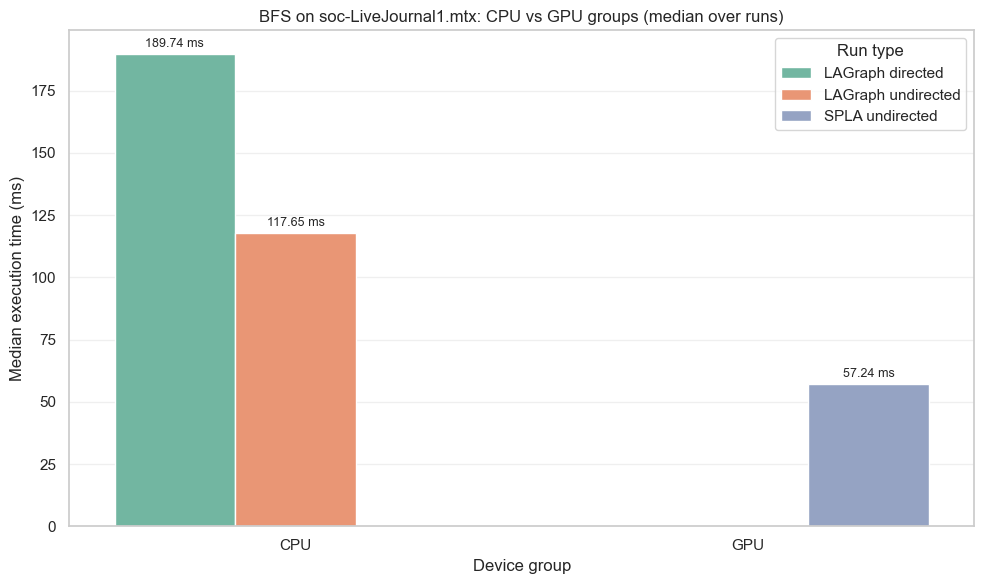

In [5]:
target_graph = 'soc-LiveJournal1.mtx'
plot_df = df_bfs[df_bfs['Graph'] == target_graph].copy()

# 1. Исправляем маппинг (убедитесь, что имена совпадают с hue_order далее)
plot_df['Variant'] = plot_df['Library'].replace({
    'SPLA': 'SPLA undirected',
    'LAGraph-Normal': 'LAGraph directed',
    'LAGraph-Sym': 'LAGraph undirected'
})

# 2. Проверка: убедитесь, что у SPLA стоит Device='GPU'
# Если в CSV для SPLA пусто в Device, заполним:
plot_df.loc[plot_df['Library'] == 'SPLA', 'Device'] = 'GPU'

summary_device = (
    plot_df
    .groupby(['Device', 'Variant'], as_index=False)['Time_ms']
    .median()
    .rename(columns={'Time_ms': 'Median_ms'})
)

plt.figure(figsize=(10, 6))
# 3. Исправляем hue_order (названия должны быть ТАКИМИ ЖЕ как в Variant)
ax = sns.barplot(
    data=summary_device,
    x='Device',
    y='Median_ms',
    hue='Variant',
    order=['CPU', 'GPU'],
    hue_order=['LAGraph directed', 'LAGraph undirected', 'SPLA undirected'], # ИСПРАВЛЕНО ЗДЕСЬ
    palette='Set2'
)

# Добавляем аннотации
for p in ax.patches:
    h = p.get_height()
    if pd.notna(h) and h > 0:
        ax.annotate(
            f'{h:.2f} ms',
            (p.get_x() + p.get_width() / 2, h),w
            ha='center', va='bottom', fontsize=9, xytext=(0, 3),
            textcoords='offset points'
        )

plt.title(f'BFS on {target_graph}: CPU vs GPU groups (median over runs)')
plt.ylabel('Median execution time (ms)')
plt.xlabel('Device group')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Run type')
plt.tight_layout()
plt.savefig("bfs/jl_mean_time.png")
plt.show()

Normality checks (Shapiro-Wilk) for raw runs in graph 3:
  LiveJournal | LAGraph directed (CPU): p=0.03947 -> not normal (n=30)
  LiveJournal | LAGraph undirected (CPU): p=0.00418 -> not normal (n=30)
  LiveJournal | SPLA directed (GPU): p=0.00000 -> not normal (n=30)
  patents | LAGraph directed (CPU): p=0.00618 -> not normal (n=30)
  patents | LAGraph undirected (CPU): p=0.00000 -> not normal (n=30)
  patents | SPLA directed (GPU): p=0.00000 -> not normal (n=30)


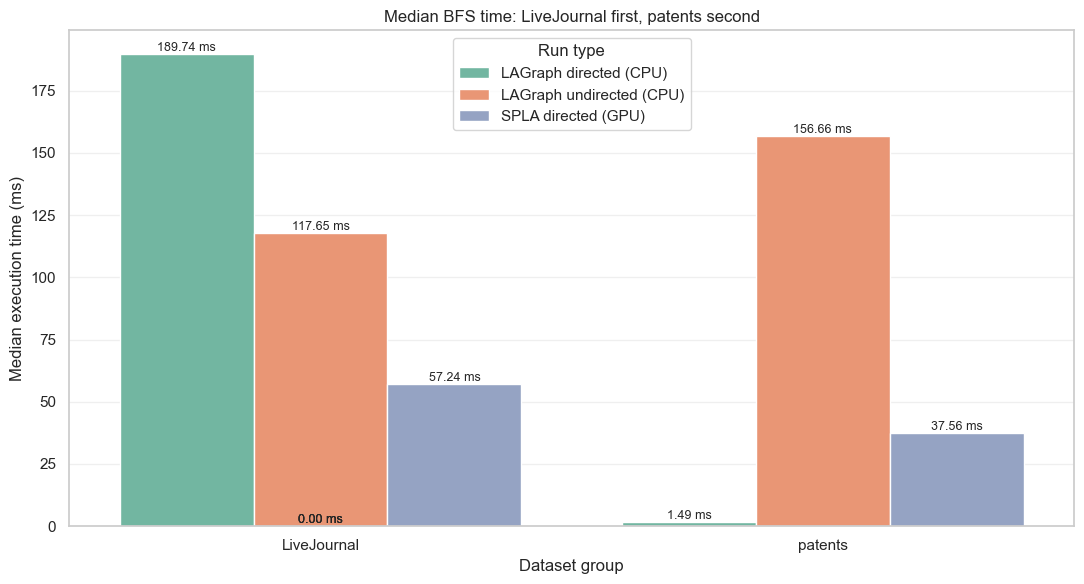

In [125]:
sns.set_theme(style="whitegrid")

base_df = df[df['Graph'].isin(['soc-LiveJournal1.mtx', 'patents.mtx'])].copy()

base_df['GraphGroup'] = base_df['Graph'].map({
    'soc-LiveJournal1.mtx': 'LiveJournal',
    'patents.mtx': 'patents'
})

variant_map = {
    'LAGraph-Sym': 'LAGraph undirected (CPU)',
    'LAGraph-Normal': 'LAGraph directed (CPU)',
    'SPLA': 'SPLA directed (GPU)'
}
base_df['Variant'] = base_df['Library'].map(variant_map)

plot_df = base_df[base_df['Variant'].notna()].copy()

summary = (
    plot_df
    .groupby(['GraphGroup', 'Variant'], as_index=False)['Time_ms']
    .median()
    .rename(columns={'Time_ms': 'Median_ms'})
)

print('Normality checks (Shapiro-Wilk) for raw runs in graph 3:')
for (graph_group, variant), g in plot_df.groupby(['GraphGroup', 'Variant']):
    sample = g['Time_ms'].dropna()
    if len(sample) >= 3:
        stat, p = stats.shapiro(sample)
        verdict = 'normal' if p > 0.05 else 'not normal'
        print(f'  {graph_group} | {variant}: p={p:.5f} -> {verdict} (n={len(sample)})')
    else:
        print(f'  {graph_group} | {variant}: n={len(sample)} (too small for Shapiro)')

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=summary,
    x='GraphGroup',
    y='Median_ms',
    hue='Variant',
    order=['LiveJournal', 'patents'],
    hue_order=['LAGraph directed (CPU)', 'LAGraph undirected (CPU)', 'SPLA directed (GPU)'],
    palette='Set2'
)

for p in ax.patches:
    h = p.get_height()
    if pd.notna(h):
        ax.annotate(
            f'{h:.2f} ms',
            (p.get_x() + p.get_width() / 2, h),
            ha='center', va='bottom', fontsize=9
        )

plt.title('Median BFS time: LiveJournal first, patents second')
plt.ylabel('Median execution time (ms)')
plt.xlabel('Dataset group')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Run type')
plt.tight_layout()
plt.savefig("bfs/all_mean_time.png")
plt.show()

/var/folders/hk/lfdr9_h57c9d_kj4145634h40000gn/T/ipykernel_24381/647022821.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gteps_df, x='Library', y='GTEPS', palette='viridis')


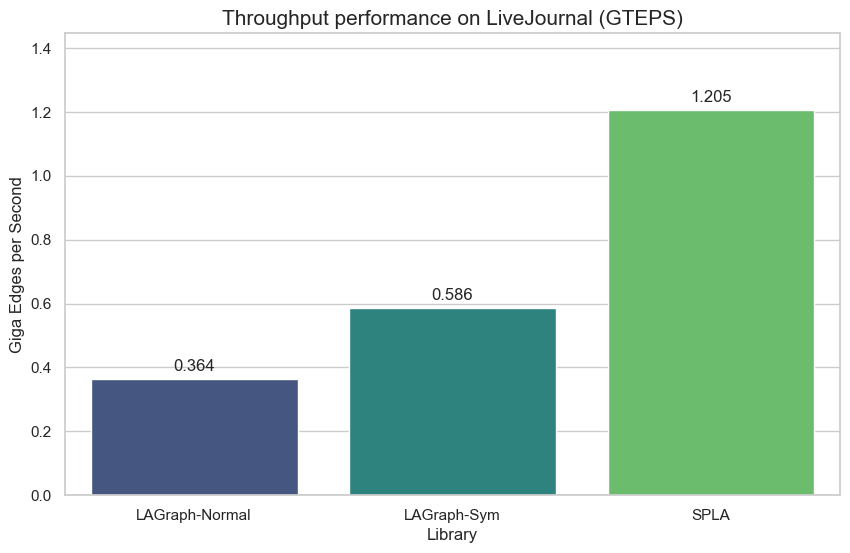

Performance LAGraph-Normal: 0.364 GTEPS
Performance LAGraph-Sym: 0.586 GTEPS
Performance SPLA: 1.205 GTEPS


In [128]:
edges_lj = {
    'soc-LiveJournal1.mtx': 68993773
}

gteps_df = base_df[base_df['Graph'] == 'soc-LiveJournal1.mtx'].copy()

gteps_df = gteps_df.groupby(['Graph', 'Library'])['Time_ms'].median().reset_index()

gteps_df['GTEPS'] = gteps_df.apply(lambda x: edges_lj[x['Graph']] / (x['Time_ms'] * 1e6), axis=1)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=gteps_df, x='Library', y='GTEPS', palette='viridis')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Throughput performance on LiveJournal (GTEPS)', fontsize=15)
plt.ylabel('Giga Edges per Second', fontsize=12)
plt.xlabel('Library', fontsize=12)
plt.ylim(0, gteps_df['GTEPS'].max() * 1.2)
plt.savefig("bfs/all_gteps.png")
plt.show()

for index, row in gteps_df.iterrows():
    print(f"Performance {row['Library']}: {row['GTEPS']:.3f} GTEPS")